In [1]:
import polars as pl

#df = pl.read_csv('weather_data_us.csv')

df = pl.read_csv('/Users/sean/Documents/comp333_project/weather_data_us.csv')



In [4]:
columns_to_check = ['TMAX', 'TMIN', 'PRCP']
num_columns = len(columns_to_check)

df_with_percentage = df.with_columns(
    (
        pl.sum_horizontal(pl.col(c).is_not_null() for c in columns_to_check).cast(pl.Float64) / num_columns
    ).alias('non_null_percentage')
)

In [5]:
df_with_percentage


ID,DATE,TMAX,TMIN,EVAP,PRCP,Latitude,Longitude,Elevation,non_null_percentage
str,str,i64,i64,str,i64,f64,f64,f64,f64
"""USS0012M13S""","""3/26/1997""",null,null,null,0,37.66,-112.74,2920.0,0.333333
"""US1OKCV0021""","""4/18/2007""",null,null,null,241,35.1715,-97.4262,355.1,0.333333
"""USC00355174""","""10/7/1999""",null,null,null,null,42.0078,-121.3186,1410.3,0.0
"""US1MDHW0012""","""10/14/2015""",null,null,null,0,39.3387,-76.9468,166.1,0.333333
"""US1TXHRS014""","""10/4/2021""",null,null,null,0,32.7061,-94.1683,53.6,0.333333
…,…,…,…,…,…,…,…,…,…
"""US1MNMW0008""","""11/14/2021""",null,null,null,5,43.6719,-93.0228,365.2,0.333333
"""US1KSJA0001""","""8/27/2014""",null,null,null,5,39.3032,-95.8141,365.8,0.333333
"""US1NEDG0029""","""6/15/2019""",null,null,null,5,41.214,-96.1908,366.1,0.333333


In [6]:
result = df_with_percentage.group_by("ID").agg(
    pl.col("non_null_percentage").mean()
)

result


ID,non_null_percentage
str,f64
"""USC00500433""",0.861515
"""USW00013940""",0.98518
"""US1MIBR0009""",0.32959
"""USC00207521""",0.899653
"""US1FLES0004""",0.33325
…,…
"""US1OHAS0008""",0.333333
"""US1NYBM0021""",0.323479
"""US1NMRA0011""",0.333333


In [7]:
result = result.sort("non_null_percentage", descending=True)
result

ID,non_null_percentage
str,f64
"""USW00024089""",1.0
"""USW00013967""",1.0
"""USW00094850""",1.0
"""USW00026451""",1.0
"""USW00013743""",1.0
…,…
"""USC00137709""",0.0
"""USC00102966""",0.0
"""US1MIHG0016""",0.0


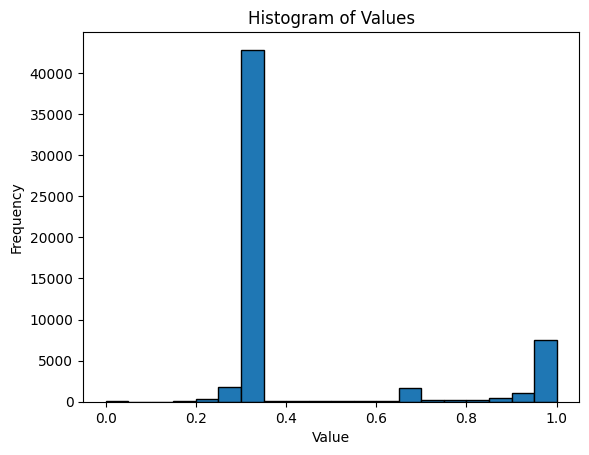

In [8]:
import matplotlib.pyplot as plt

plt.hist(result["non_null_percentage"], bins=20, edgecolor='black')
plt.title("Histogram of Values")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()


In [9]:
result_greater_than_98 = result.filter(pl.col("non_null_percentage") >= 0.98)

In [10]:
result_greater_than_98

ID,non_null_percentage
str,f64
"""USW00024089""",1.0
"""USW00013967""",1.0
"""USW00094850""",1.0
"""USW00026451""",1.0
"""USW00013743""",1.0
…,…
"""USC00354060""",0.980034
"""USC00459074""",0.98003
"""USC00419088""",0.980015


In [11]:
values_list = result_greater_than_98["ID"].to_list()


In [12]:
filtered_df = df.filter(pl.col("ID").is_in(values_list))


In [13]:
#feature engineering a little

filtered_df
filtered_df = filtered_df.drop("EVAP")

filtered_df = filtered_df.with_columns([
    (pl.col("TMAX") / 10).alias("TMAX"),
    (pl.col("TMIN") / 10).alias("TMIN")
])

In [15]:
filtered_df.write_csv("filtered_df.csv")


In [16]:
summary = filtered_df.describe()
summary

statistic,ID,DATE,TMAX,TMIN,PRCP,Latitude,Longitude,Elevation
str,str,str,f64,f64,f64,f64,f64,f64
"""count""","""42482360""","""42482360""",4.2208112e7,4.2189643e7,4.2201752e7,4.248236e7,4.248236e7,4.248236e7
"""null_count""","""0""","""0""",274248.0,292717.0,280608.0,0.0,0.0,0.0
"""mean""",null,null,17.138579,4.574703,24.60613,40.229175,-99.182832,744.143416
"""std""",null,null,11.911995,11.311118,78.110834,6.085418,16.749835,818.754502
"""min""","""US009052008""","""1/1/1992""",-99.9,-115.0,0.0,19.2706,-170.2228,-999.9
"""25%""",null,null,8.3,-2.5,0.0,36.1561,-111.4336,165.5
"""50%""",null,null,18.3,4.7,0.0,40.4644,-97.7019,351.1
"""75%""",null,null,26.7,12.8,8.0,44.0206,-85.8889,1204.9
"""max""","""USW00096408""","""9/9/2021""",5537.2,3046.0,53365.0,71.2869,174.1,3541.8


In [17]:
import polars as pl
import polars.selectors as cs

def quantDDA(df_input: pl.DataFrame, sample_size: int = 100_000) -> pl.DataFrame:
    
    # Systematic sample for large datasets
    if len(df_input) > sample_size:
        step = len(df_input) // sample_size
        df_input = df_input.gather_every(step)
        print(f"Sampled every {step}th row → {len(df_input):,} rows used for stats")

    numeric_cols = df_input.select(cs.numeric()).columns
    total_obs = len(df_input)

    stats = [
        pl.lit(total_obs).alias("Total_Obs"),
        cs.all().count().name.prefix("Entries_"),
        cs.all().n_unique().name.prefix("Unique_"),
        cs.all().null_count().name.prefix("Null_"),
    ]

    for col in numeric_cols:
        series = df_input.get_column(col)
        q1 = series.quantile(0.25)
        q2 = series.quantile(0.5)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        p01, p99 = series.quantile(0.01), series.quantile(0.99)
        stats.extend([
            ((pl.col(col) < (q1 - 1.5 * iqr)) | (pl.col(col) > (q3 + 1.5 * iqr))).sum().alias(f"Outliers_{col}"),
            ((pl.col(col) < p01) | (pl.col(col) > p99)).sum().alias(f"Extreme_{col}"),
            pl.col(col).mode().first().alias(f"Mode_{col}"),
            pl.col(col).mean().round(2).alias(f"Mean_{col}"),
            pl.col(col).std().round(2).alias(f"StdDev_{col}"),
            pl.col(col).max().alias(f"Max_{col}"),
            pl.col(col).min().alias(f"Min_{col}"),
            pl.lit(q1).alias(f"Q1_{col}"),
            pl.lit(q2).alias(f"Q2_{col}"),
            pl.lit(q3).alias(f"Q3_{col}"),
            pl.col(col).skew().round(4).alias(f"Skew_{col}"),
            pl.col(col).kurtosis().round(4).alias(f"Kurt_{col}"),
        ])

    stats.append(
        ((cs.all().count() / total_obs) * 100).round(2).name.prefix("NonMissingPct_")
    )

    res_wide = df_input.select(stats)
    res_long = res_wide.unpivot().with_columns(
        pl.col("variable").str.splitn("_", 2).struct.field("field_0").alias("Stat"),
        pl.col("variable").str.splitn("_", 2).struct.field("field_1").alias("Feature")
    )

    final_df = res_long.pivot(index="Feature", on="Stat", values="value")
    final_df = final_df.fill_null("-")

    if "NonMissingPct" in final_df.columns:
        cols = [c for c in final_df.columns if c != "NonMissingPct"] + ["NonMissingPct"]
        final_df = final_df.select(cols)

    return final_df

In [18]:
quantDDA(filtered_df)

Sampled every 424th row → 100,195 rows used for stats


Feature,Total,Entries,Unique,Null,Outliers,Extreme,Mode,Mean,StdDev,Max,Min,Q1,Q2,Q3,Skew,Kurt,NonMissingPct
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Obs""",100195.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""ID""",null,100195.0,5354.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,100.0
"""DATE""",null,100195.0,10592.0,0.0,null,null,null,null,null,null,null,null,null,null,null,null,100.0
"""TMAX""",null,99551.0,635.0,644.0,166.0,1879.0,28.3,17.17,11.84,50.1,-51.3,8.3,18.3,26.7,-0.3969,-0.4122,99.36
"""TMIN""",null,99496.0,617.0,699.0,677.0,1749.0,0.0,4.6,10.77,95.7,-63.7,-2.3,4.9,12.8,-0.3393,0.0174,99.3
"""PRCP""",null,99493.0,493.0,702.0,19740.0,982.0,0.0,24.44,76.31,2471.0,0.0,0.0,0.0,8.0,6.6335,76.3181,99.3
"""Latitude""",null,100195.0,4991.0,0.0,2394.0,1988.0,45.19,40.23,6.06,71.2869,19.2706,36.1839,40.45,44.0217,0.6388,2.7006,100.0
"""Longitude""",null,100195.0,5164.0,0.0,1060.0,1992.0,-110.68,-99.12,16.72,174.1,-170.2228,-111.42,-97.6003,-85.8958,-0.4177,2.539,100.0
"""Elevation""",null,100195.0,2710.0,0.0,3194.0,1887.0,3.0,744.71,820.27,3541.8,-999.9,166.1,350.5,1204.0,1.3137,0.7504,100.0


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import pandas as pd
import numpy as np


def vizDDA(df_input: pl.DataFrame, sample_size: int = 50_000):

    if len(df_input) > sample_size:
        step = len(df_input) // sample_size
        df_input = df_input.gather_every(step)
        print(f"Sampled every {step}th row → {len(df_input):,} rows used for viz")
        
    df_input = df_input.drop("ID")


    
    headers = df_input.columns
    n_obs = len(df_input)

    stat_data = {
        "#Observations": [n_obs] * len(headers),
        "#Entries": [df_input[col].drop_nulls().len() for col in headers],
        "#Unique": [df_input[col].n_unique() for col in headers],
    }

    stat_df = pd.DataFrame(stat_data, index=headers)
    stat_df["Is_Unique"] = ~(
        (stat_df["#Observations"] == stat_df["#Entries"]) &
        (stat_df["#Observations"] == stat_df["#Unique"])
    )

    cols_to_plot = stat_df[stat_df["Is_Unique"]].index.tolist()
    df_filtered = df_input.select(cols_to_plot)

    # ✅ Convert ONCE outside the loop
    df_pd = df_filtered.to_pandas()

    cols = df_filtered.columns
    n = len(cols)

    # ✅ Pre-compute n_unique and dtype for all columns once
    n_unique = {col: df_filtered[col].n_unique() for col in cols}

    def is_numeric(col):
        return df_filtered[col].dtype in (
            pl.Int8, pl.Int16, pl.Int32, pl.Int64,
            pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
            pl.Float32, pl.Float64
        )

    is_num = {col: is_numeric(col) for col in cols}

    fig, axes = plt.subplots(n, n, figsize=(n * 3, n * 3))
    if n == 1:
        axes = np.array([[axes]])

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            col_x = cols[j]
            col_y = cols[i]

            is_x_num = is_num[col_x]
            is_y_num = is_num[col_y]
            is_x_messy = n_unique[col_x] > 20 and not is_x_num
            is_y_messy = n_unique[col_y] > 20 and not is_y_num

            if i == j:
                if is_x_num:
                    sns.histplot(data=df_pd[col_x], ax=ax, kde=True)
                else:
                    if is_x_messy:
                        ax.text(0.5, 0.5,
                                f"Too many unique \nvalues in {col_x}: ({n_unique[col_x]})",
                                ha="center", va="center")
                    else:
                        sns.countplot(data=df_pd, x=col_x, ax=ax)
                        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)
                ax.set_title(f"Dist of {col_x}")

            else:
                if is_x_messy and is_y_messy:
                    if is_x_num and is_y_num:
                        # ✅ Sample large datasets for scatterplots
                        plot_data = df_pd[[col_x, col_y]].dropna()
                        if len(plot_data) > 5000:
                            plot_data = plot_data.sample(5000)
                        sns.scatterplot(data=plot_data, x=col_x, y=col_y, ax=ax)
                    else:
                        ax.text(0.5, 0.5,
                                f"High Cardinality\n{col_x}: {n_unique[col_x]} unique\n{col_y}: {n_unique[col_y]} unique",
                                ha="center", va="center", fontsize=9)
                    ax.set_xlabel(col_x, fontsize=8)
                    ax.set_ylabel(col_y, fontsize=8)

                elif is_x_num and is_y_num:
                    plot_data = df_pd[[col_x, col_y]].dropna()
                    if len(plot_data) > 5000:
                        plot_data = plot_data.sample(5000)
                    sns.scatterplot(data=plot_data, x=col_x, y=col_y, ax=ax)
                    ax.set_xlabel(col_x, fontsize=8)
                    ax.set_ylabel(col_y, fontsize=8)

                elif is_x_num != is_y_num:
                    df_temp = df_pd[[col_x, col_y]].dropna()
                    if not is_x_num and is_x_messy:
                        top_cats = df_temp[col_x].value_counts().head(10).index
                        df_temp = df_temp[df_temp[col_x].isin(top_cats)]
                    if not is_y_num and is_y_messy:
                        top_cats = df_temp[col_y].value_counts().head(10).index
                        df_temp = df_temp[df_temp[col_y].isin(top_cats)]
                    sns.boxplot(data=df_temp, x=col_x, y=col_y, ax=ax)
                    ax.set_xlabel(col_x, fontsize=8)
                    ax.set_ylabel(col_y, fontsize=8)
                    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=7)

                else:
                    df_temp = df_pd[[col_x, col_y]].dropna()
                    if is_x_messy:
                        top_x = df_temp[col_x].value_counts().head(10).index
                        df_temp = df_temp[df_temp[col_x].isin(top_x)]
                    if is_y_messy:
                        top_y = df_temp[col_y].value_counts().head(10).index
                        df_temp = df_temp[df_temp[col_y].isin(top_y)]
                    ct = pd.crosstab(df_temp[col_y], df_temp[col_x])
                    sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
                    ax.set_xlabel(col_x, fontsize=8)
                    ax.set_ylabel(col_y, fontsize=8)
                    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=7)
                    plt.setp(ax.yaxis.get_majorticklabels(), fontsize=7)

    plt.tight_layout()
    plt.show()

    # Missing values heatmap
    fig, ax = plt.subplots(figsize=(14, max(6, len(df_input.columns) * 0.4)))
    sns.heatmap(df_pd.isnull(), cbar=True, cmap='viridis', yticklabels=False, ax=ax)
    ax.set_title('Missing Values Heatmap (Yellow = Missing)', fontsize=14, pad=20)
    ax.set_xlabel('Columns', fontsize=12)
    ax.set_ylabel('Observations', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

Sampled every 849th row → 50,039 rows used for viz


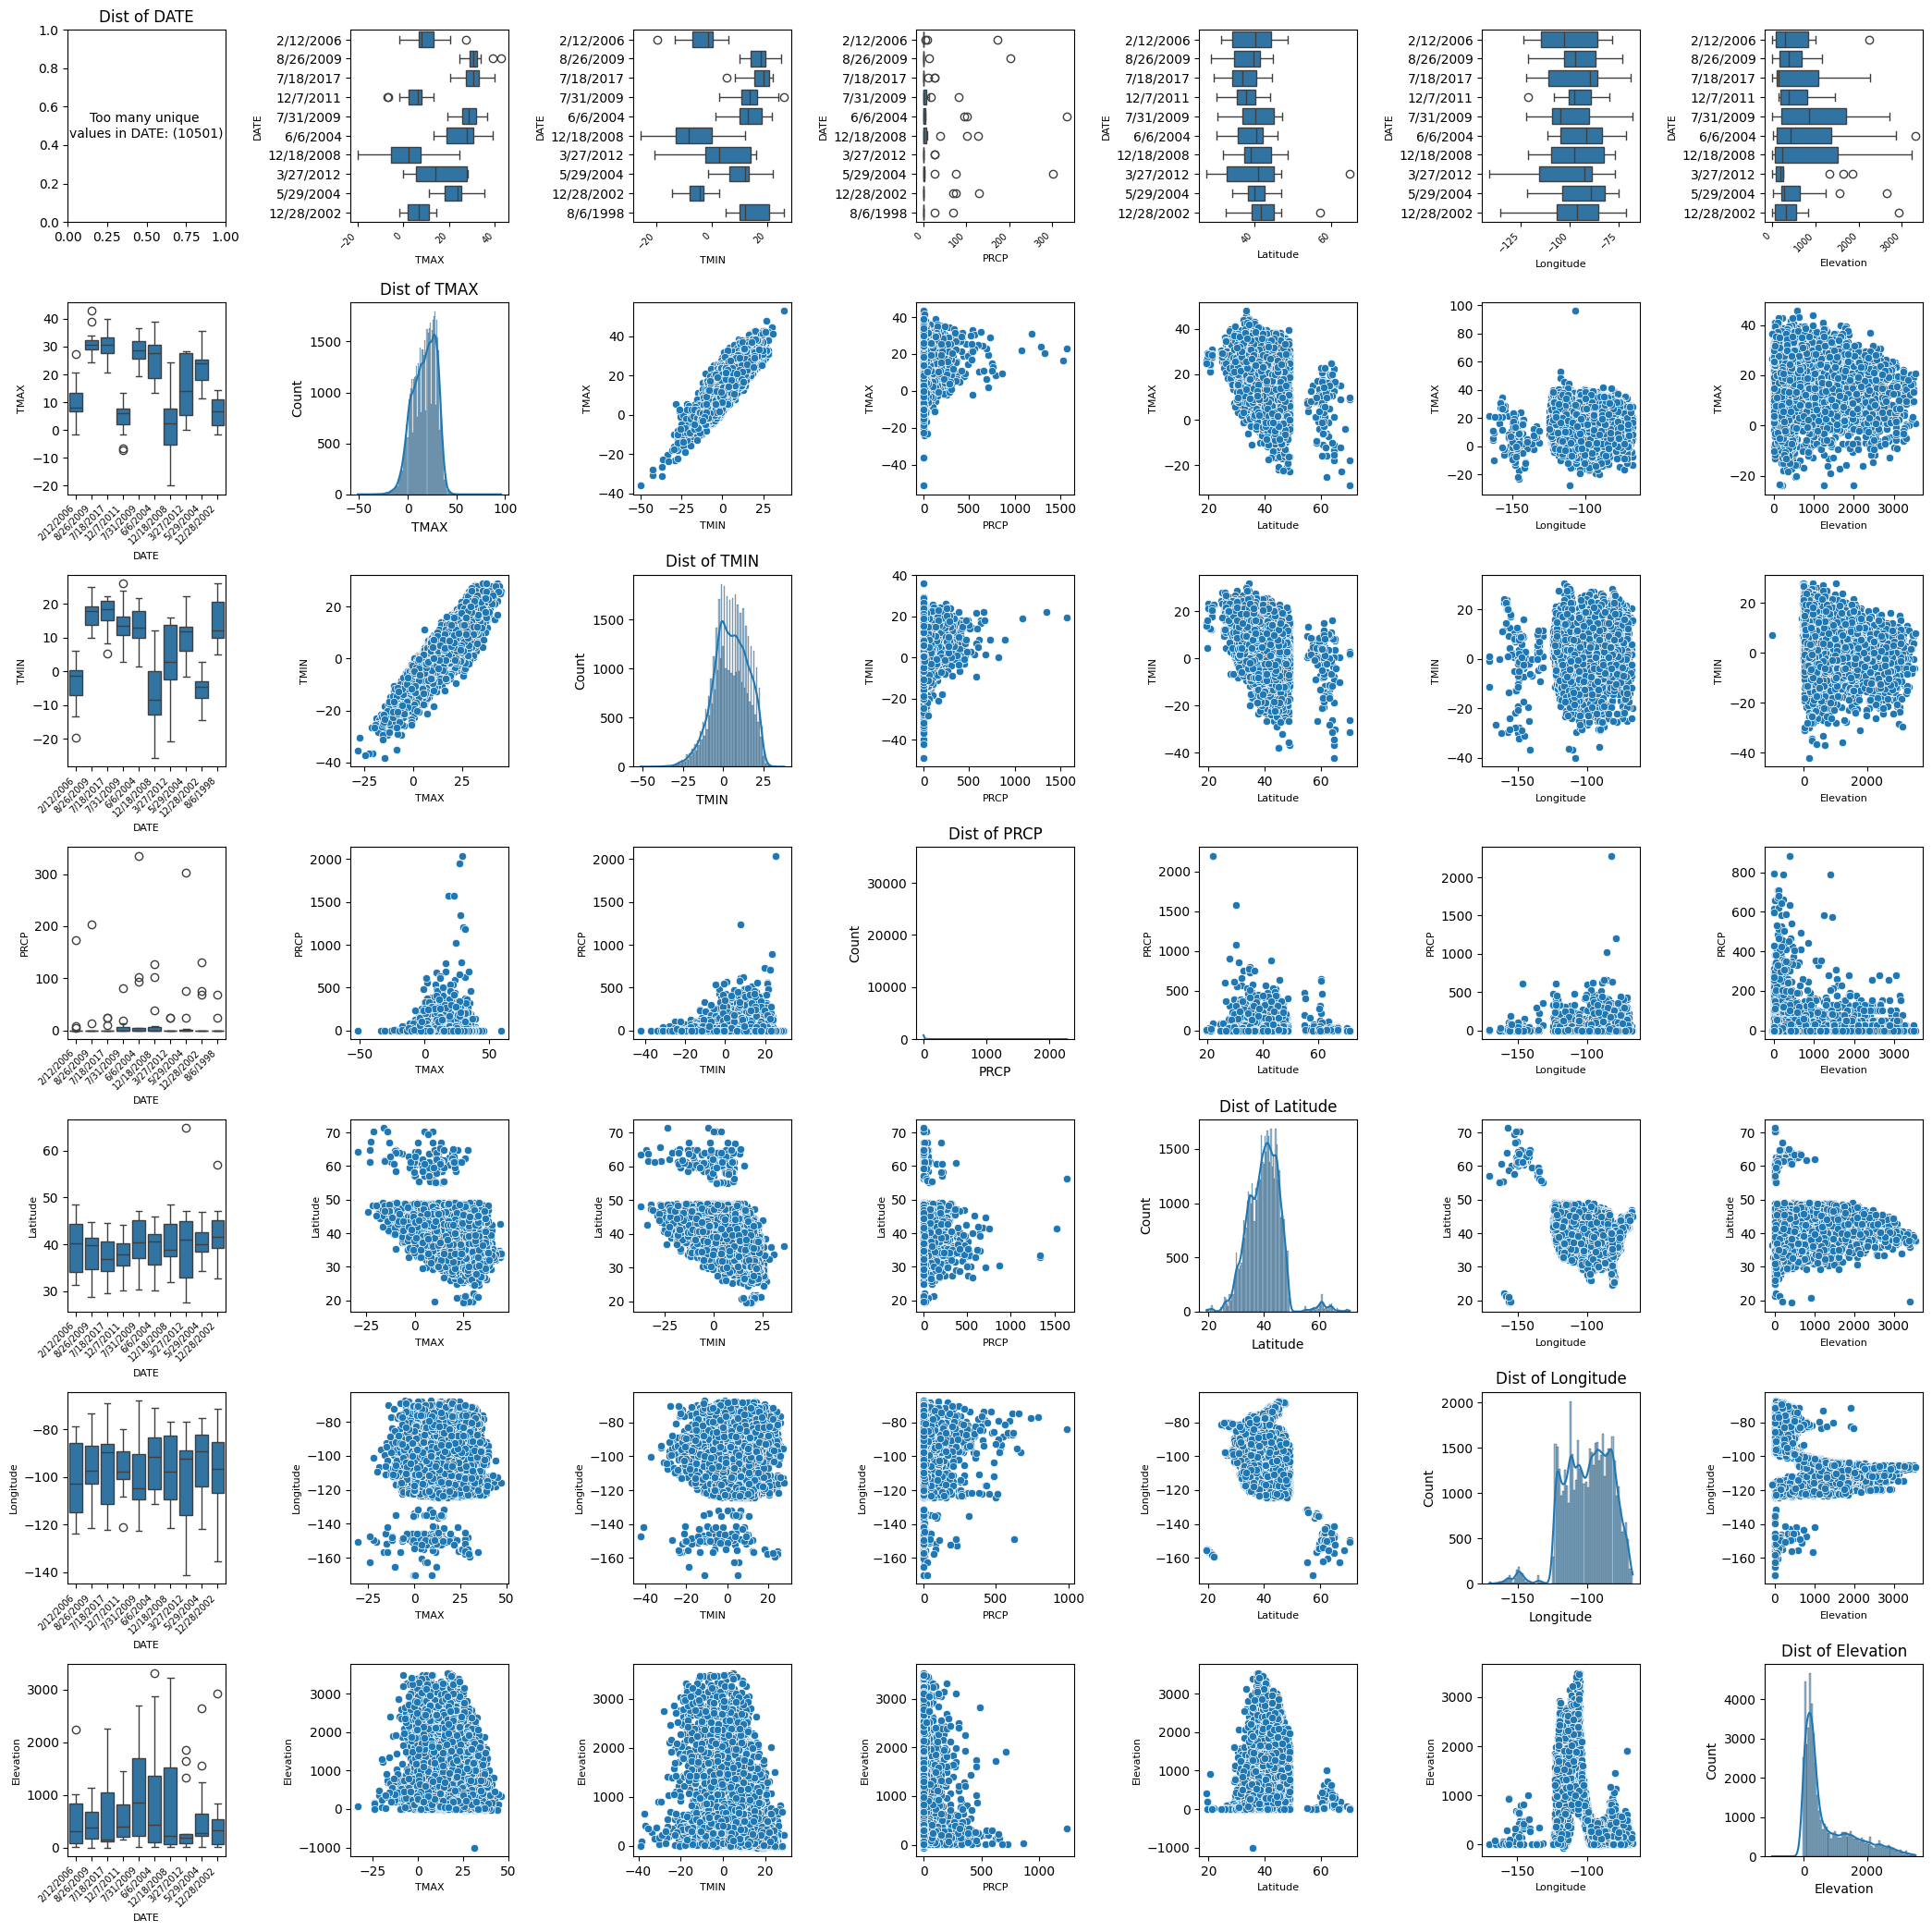

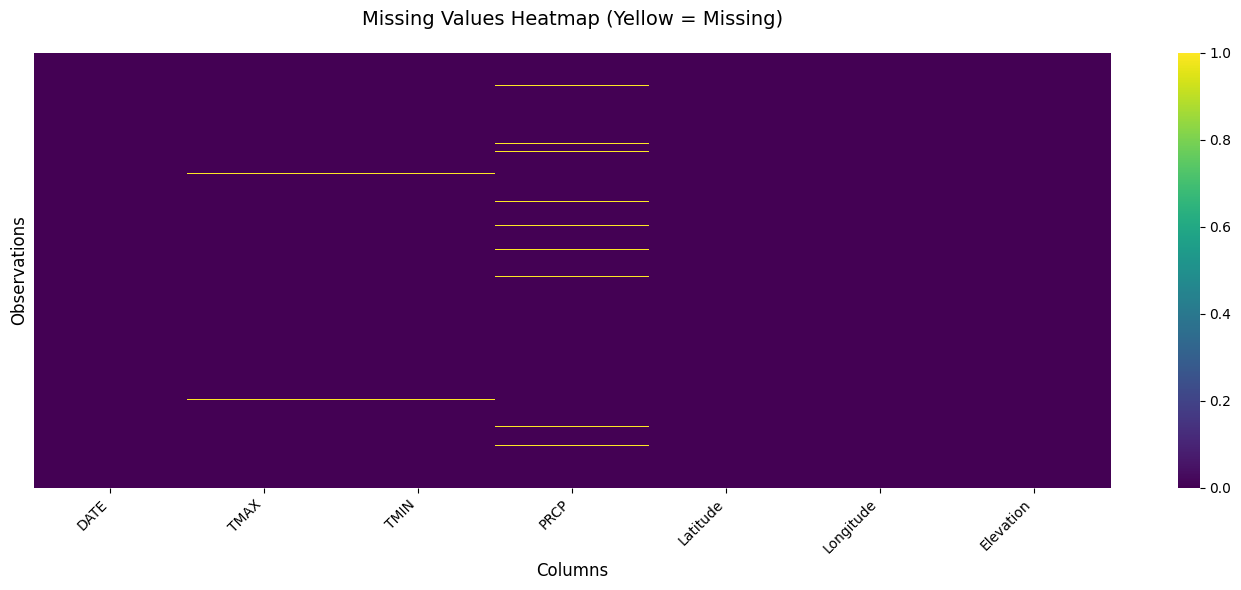

In [21]:
vizDDA(filtered_df)

12369821


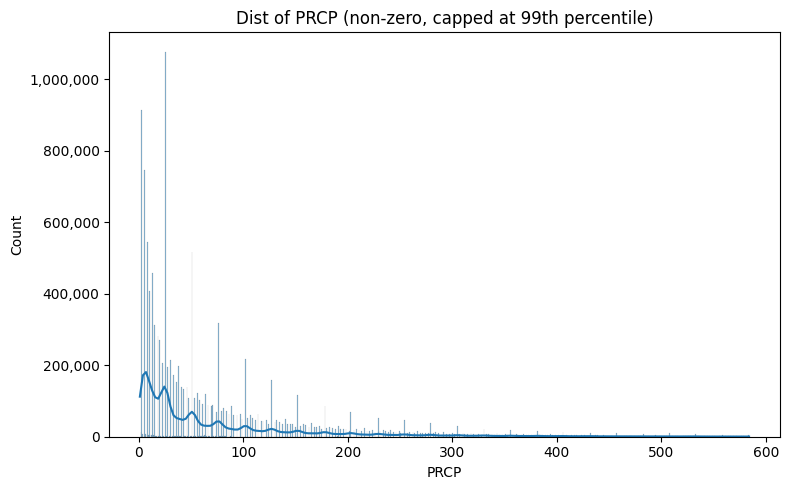

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
prcp = filtered_df["PRCP"].drop_nulls()
prcp = prcp.filter(prcp > 0)
print(prcp.count())
cap = prcp.quantile(0.99)
prcp_capped = prcp.filter(prcp <= cap).to_pandas()
sns.histplot(data=prcp_capped, ax=ax, kde=True)
ax.set_title("Dist of PRCP (non-zero, capped at 99th percentile)")
ax.set_xlabel("PRCP")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

Step 4: Can we predict if it will rain tomorrow?

In [23]:
import pandas as pd
import numpy as np

In [24]:
# Only parse if DATE is still a String type
if filtered_df["DATE"].dtype == pl.Utf8 or filtered_df["DATE"].dtype == pl.String:
    filtered_df = filtered_df.with_columns(
        pl.col("DATE").str.strptime(pl.Date, format="%m/%d/%Y").alias("DATE")
    )

# Safe to sort now either way
filtered_df = filtered_df.sort(["ID", "DATE"])

In [25]:
#RainTomorrow: tomorrow’s rain label (shifted within each station)
#.over("ID") prevents mixing stations
filtered_df = filtered_df.with_columns(
    (pl.col("PRCP") > 0).cast(pl.Int8).alias("RainToday")
)

filtered_df = filtered_df.with_columns(
    pl.col("RainToday").shift(-1).over("ID").alias("RainTomorrow")
).drop_nulls(subset=["RainTomorrow"])



In [26]:
#model_df = filtered_df.select(["DATE", "TMAX", "TMIN", "PRCP", "RainTomorrow"])
model_df = filtered_df.select(["DATE", "TMAX", "TMIN", "PRCP", "RainTomorrow"])

In [27]:
#time-based split
pdf = model_df.to_pandas()
pdf["DATE"] = pd.to_datetime(pdf["DATE"])
pdf = pdf.sort_values("DATE")

train_end = pdf["DATE"].quantile(0.70)
val_end   = pdf["DATE"].quantile(0.85)

train_df = pdf[pdf["DATE"] <= train_end]
val_df   = pdf[(pdf["DATE"] > train_end) & (pdf["DATE"] <= val_end)]
test_df  = pdf[pdf["DATE"] > val_end]

X_train = train_df.drop(columns=["RainTomorrow", "DATE"])
y_train = train_df["RainTomorrow"].astype(int)

X_val = val_df.drop(columns=["RainTomorrow", "DATE"])
y_val = val_df["RainTomorrow"].astype(int)

X_test = test_df.drop(columns=["RainTomorrow", "DATE"])
y_test = test_df["RainTomorrow"].astype(int)

print("Train dates:", train_df["DATE"].min(), "->", train_df["DATE"].max())
print("Val dates:  ", val_df["DATE"].min(), "->", val_df["DATE"].max())
print("Test dates: ", test_df["DATE"].min(), "->", test_df["DATE"].max())

print("\nClass balance (train):")
print(y_train.value_counts(normalize=True))

Train dates: 1992-01-01 00:00:00 -> 2013-06-28 00:00:00
Val dates:   2013-06-29 00:00:00 -> 2017-08-29 00:00:00
Test dates:  2017-08-30 00:00:00 -> 2021-12-30 00:00:00

Class balance (train):
RainTomorrow
0    0.708925
1    0.291075
Name: proportion, dtype: float64


In [28]:
#training 
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=6,           # baseline complexity control
    min_samples_leaf=50,   # stabilizes splits so we dont overfit
    random_state=42
)

tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",50
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [29]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    classification_report, confusion_matrix
)

# Validation
val_pred = tree.predict(X_val)
val_prob = tree.predict_proba(X_val)[:, 1]

print("VAL Accuracy:", accuracy_score(y_val, val_pred))
print("VAL AUC:", roc_auc_score(y_val, val_prob))
print("VAL Confusion Matrix:\n", confusion_matrix(y_val, val_pred))
print("\nVAL Classification Report:\n", classification_report(y_val, val_pred))

VAL Accuracy: 0.7229979538804527
VAL AUC: 0.688937277334255
VAL Confusion Matrix:
 [[4126569  311945]
 [1440945  448617]]

VAL Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.93      0.82   4438514
           1       0.59      0.24      0.34   1889562

    accuracy                           0.72   6328076
   macro avg       0.67      0.58      0.58   6328076
weighted avg       0.70      0.72      0.68   6328076



In [30]:
# Test (final)
test_pred = tree.predict(X_test)
test_prob = tree.predict_proba(X_test)[:, 1]

print("TEST Accuracy:", accuracy_score(y_test, test_pred))
print("TEST AUC:", roc_auc_score(y_test, test_prob))
print("TEST Confusion Matrix:\n", confusion_matrix(y_test, test_pred))
print("\nTEST Classification Report:\n", classification_report(y_test, test_pred))

TEST Accuracy: 0.7241469107889942
TEST AUC: 0.6911037198432569
TEST Confusion Matrix:
 [[4128032  319576]
 [1426136  454668]]

TEST Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.93      0.83   4447608
           1       0.59      0.24      0.34   1880804

    accuracy                           0.72   6328412
   macro avg       0.67      0.58      0.58   6328412
weighted avg       0.70      0.72      0.68   6328412



Accuracy: What percentage of all days did we predict correctly?
Precision: Of the days we predicted rain, how many actually rained?
Recall: Of all actual rainy days, how many did we correctly detect?
F1-Score: How balanced are precision and recall
ROC AUC: How well does the model separate rainy days from non-rainy days? 
(0.5 → random guessing, 1.0 → perfect separation)


In [31]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tree.feature_importances_
}).sort_values("Importance", ascending=False)

importance_df

,Feature,Importance
2,PRCP,0.883078
0,TMAX,0.072120
1,TMIN,0.044802
